# Problem Statement & Objective:

The goal of this task is to segment customers into distinct groups based on their behavior (e.g., income and spending).

This helps businesses:

1. Target customers effectively
2. Improve marketing strategies
3. Increase sales and retention

# In simple terms:
“Group similar customers together and treat each group differently.”

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
#Load Dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Check dataset structure
print("\nDataset Info:")
print(df.info())


First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [5]:
#Data Preprocessing

# Drop CustomerID
df = df.drop("CustomerID", axis=1)

# Convert 'Genre' (Male/Female) into numeric values
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


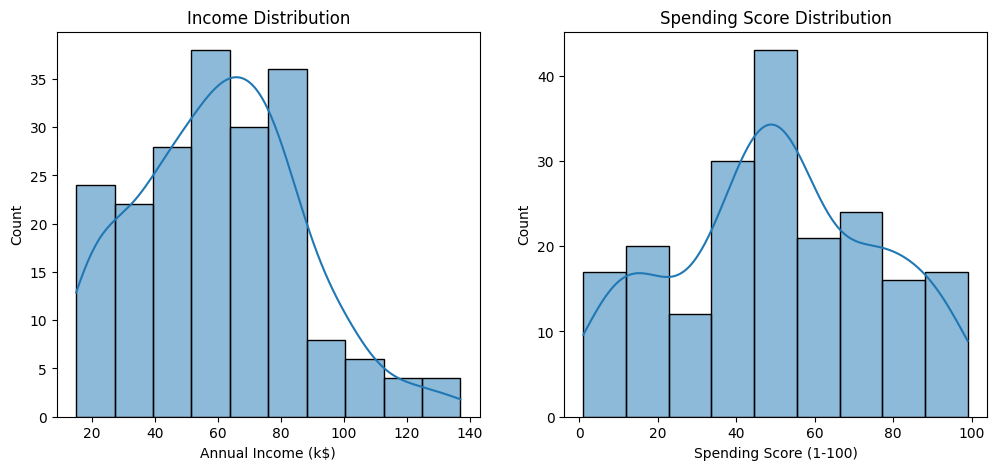

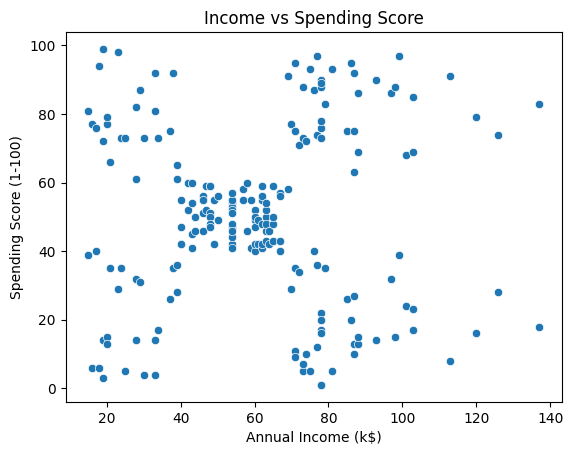

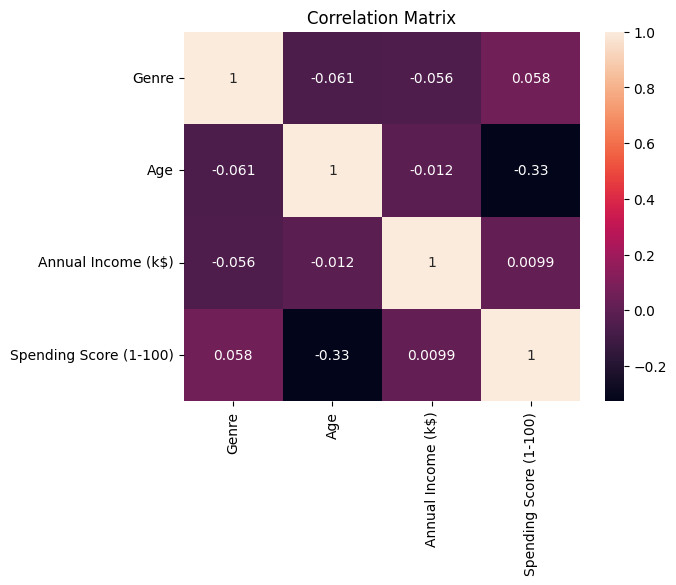

In [7]:
# Exploratory Data Analysis (EDA)
# Distribution of Income and Spending Score
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title("Income Distribution")

plt.subplot(1,2,2)
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

# Relationship between Income and Spending Score
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Income vs Spending Score")
plt.show()

# Correlation Heatmap
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [9]:
# Feature Scaling
# K-Means works better when data is scaled
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

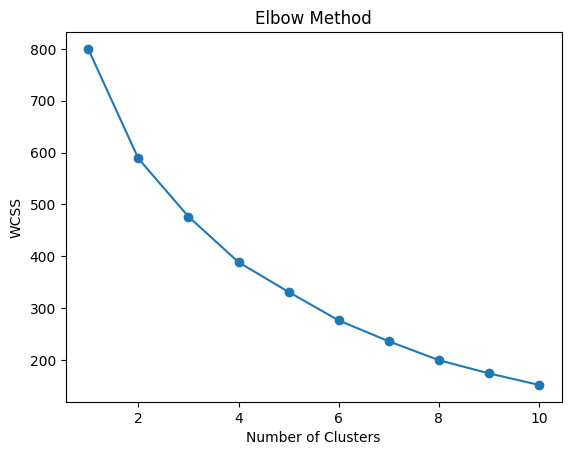

In [10]:
# Elbow Method to find optimal K
wcss = []   # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
# Apply K-Means Clustering

# Based on elbow method, choose K = 5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
df['Cluster'] = clusters

print("Clustered Data:")
print(df.head())

Clustered Data:
   Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0      0   19                  15                      39        3
1      0   21                  15                      81        3
2      1   20                  16                       6        3
3      1   23                  16                      77        3
4      1   31                  17                      40        3


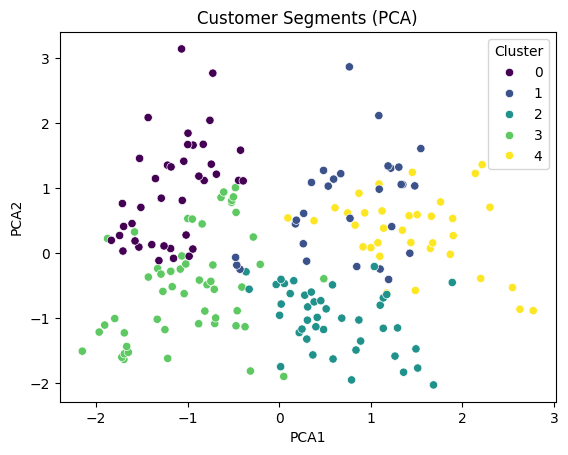

In [12]:
# PCA (Dimensionality Reduction)
# Reduce features to 2 dimensions for visualization

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Add PCA columns to dataset
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

# Plot clusters
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis')
plt.title("Customer Segments (PCA)")
plt.show()

In [13]:
# Analyze Cluster Characteristics
# View average values of each cluster
cluster_summary = df.groupby('Cluster').mean()

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
            Genre        Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                                    
0        0.538462  32.692308           86.538462               82.128205   
1        0.551724  36.482759           89.517241               18.000000   
2        1.000000  49.813953           49.232558               40.069767   
3        0.592593  24.907407           39.722222               61.203704   
4        0.000000  55.714286           53.685714               36.771429   

             PCA1      PCA2  
Cluster                      
0       -1.151299  0.959764  
1        0.739004  0.744866  
2        0.606362 -1.008718  
3       -0.992308 -0.501973  
4        1.456589  0.327129  


# Final Conclusion

- Customers were segmented into 5 clusters using K-Means.
- Each cluster represents a unique group based on income and spending score.
- High-income high-spending customers are premium targets.
- Low-income high-spending customers respond well to discounts.
- Businesses can use these insights to improve marketing strategies and increase sales.